In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
dfs

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],BEND-DIE_VERTICAL_Movement_[mm],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,,,,,,,,,,,,
0.00,2,0.135068,0.817045,0.293651,0.436154,0.397692,0.107143,0.985937,0.757580,0.59375,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.999849
0.05,2,0.135068,0.817045,0.285714,0.436154,0.397822,0.107143,0.985937,0.750271,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999842
0.10,2,0.135068,0.817045,0.293651,0.436154,0.398065,0.107143,0.984375,0.698300,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999540
0.15,2,0.136307,0.817045,0.293651,0.436154,0.397887,0.107143,0.985937,0.585460,0.62500,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.998401
0.20,2,0.135068,0.817045,0.285714,0.436154,0.397741,0.107143,0.984375,0.476972,0.65625,0.999967,1.000000,0.456468,0.570124,0.000002,0.900879,0.000373,0.997003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,318,0.074349,0.874371,0.285714,0.419532,0.414799,0.785714,0.929688,0.793256,0.43750,0.000007,0.998132,0.456468,0.000004,0.984199,0.049412,0.000373,0.999849
86.35,318,0.074349,0.872135,0.285714,0.419532,0.414653,0.785714,0.929688,0.793244,0.40625,0.000007,0.998791,0.456468,0.000004,0.984200,0.049412,0.000373,0.999849
86.40,318,0.075589,0.875591,0.285714,0.419532,0.414929,0.785714,0.929688,0.793176,0.40625,0.000007,0.999315,0.456468,0.000004,0.984199,0.049412,0.000373,0.999849


In [14]:
import numpy as np

# Keep features with variance above a threshold
variance_threshold = 0.09
dfs = dfs.loc[:, dfs.var() > variance_threshold]
dfs

,Experiment_ID,BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,
0.00,2,0.999967,1.000000,0.570124,0.000005,0.900879,0.999849
0.05,2,0.999967,1.000000,0.570124,0.000004,0.900879,0.999842
0.10,2,0.999967,1.000000,0.570124,0.000004,0.900879,0.999540
0.15,2,0.999967,1.000000,0.570124,0.000005,0.900879,0.998401
0.20,2,0.999967,1.000000,0.570124,0.000002,0.900879,0.997003
...,...,...,...,...,...,...,...
86.30,318,0.000007,0.998132,0.000004,0.984199,0.049412,0.999849
86.35,318,0.000007,0.998791,0.000004,0.984200,0.049412,0.999849
86.40,318,0.000007,0.999315,0.000004,0.984199,0.049412,0.999849


In [16]:
groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)

# Replace NaN with 0
Y = np.nan_to_num(y, nan=0.0)



groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)


X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)
Y = np.nan_to_num(y, nan=0.0)[:,:,1:-1]
print("Shape:", X.shape, Y.shape)  

Shape: (315, 1743, 6) (315, 47, 3)


In [17]:
from torch.utils.data import Dataset, DataLoader
import torch

class BendingDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


In [18]:
class AngleAttention(nn.Module):
    def __init__(self, hidden_dim, num_angles):
        super().__init__()
        self.num_angles = num_angles
        # One linear layer per angle
        self.attn_layers = nn.ModuleList([nn.Linear(hidden_dim, 1) for _ in range(num_angles)])

    def forward(self, lstm_out):
        # lstm_out: (batch, seq_len, hidden_dim)
        batch_size, seq_len, hidden_dim = lstm_out.shape
        contexts = []
        attn_weights_all = []

        for attn_layer in self.attn_layers:
            weights = torch.softmax(attn_layer(lstm_out), dim=1)  # (batch, seq_len, 1)
            context = torch.sum(weights * lstm_out, dim=1)         # (batch, hidden_dim)
            contexts.append(context.unsqueeze(1))                  # (batch, 1, hidden_dim)
            attn_weights_all.append(weights)                       # (batch, seq_len, 1)

        # Concatenate contexts: (batch, num_angles, hidden_dim)
        contexts = torch.cat(contexts, dim=1)
        # Concatenate attention weights: (batch, seq_len, num_angles)
        attn_weights_all = torch.cat(attn_weights_all, dim=2)
        return contexts, attn_weights_all

class SequenceToAnglesPerAngleAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_shape, num_layers=2):
        super().__init__()
        self.num_angles = output_shape[0]
        self.num_features = output_shape[1]
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, 
                            batch_first=True, bidirectional=True)
        self.attention = AngleAttention(hidden_dim*2, self.num_angles)
        self.fc = nn.Linear(hidden_dim*2, self.num_features)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)                       # (batch, seq_len, hidden*2)
        contexts, attn_weights = self.attention(lstm_out) # contexts: (batch, num_angles, hidden*2)
        # Predict features per angle
        outputs = self.fc(contexts)                      # (batch, num_angles, num_features)
        return outputs, attn_weights


In [19]:
dataset = BendingDataset(X, Y)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SequenceToAnglesPerAngleAttention(input_dim=X.shape[2],
                                          hidden_dim=16,
                                          output_shape=(Y.shape[1], Y.shape[2])).to(device)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-2)
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds, _ = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.6f}")


Epoch 1/50, Loss: 0.028516


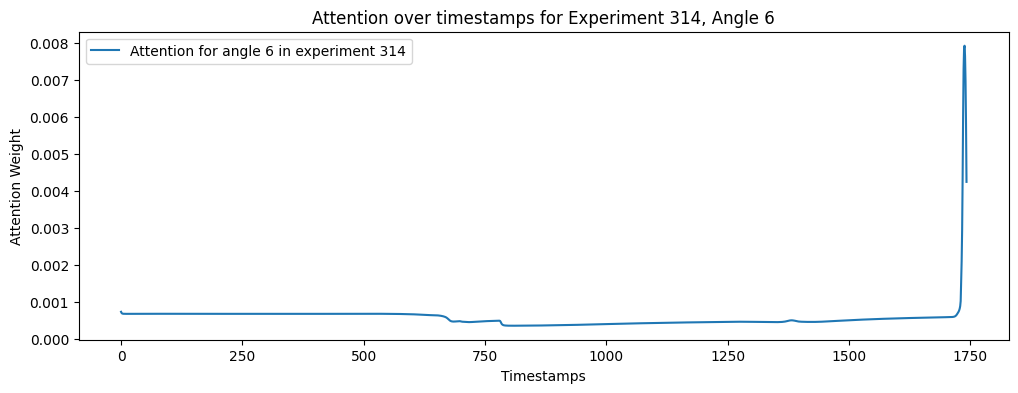

In [117]:
model.eval()
experiment_idx = 314  # choose experiment
angle_idx = 6     # choose angle (0 to 46)

with torch.no_grad():
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    preds, attn_weights = model(X_tensor)  # attn_weights: (batch, seq_len, 1)
    
    # Extract for the specific experiment
    attn_exp = attn_weights[experiment_idx, :, angle_idx].cpu().numpy()  # shape: (seq_len,)
    
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(attn_exp, label=f'Attention for angle {angle_idx} in experiment {experiment_idx}')
plt.xlabel("Timestamps")
plt.ylabel("Attention Weight")
plt.title(f"Attention over timestamps for Experiment {experiment_idx}, Angle {angle_idx}")
plt.legend()
plt.show()


In [121]:
attn_weights.shape

torch.Size([315, 1743, 47])